# Part 3: Model Comparison with SVM

In this notebook, you will compare two different multi-class SVM implementations on the Maine bills dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Load the dataset from data/X.json and data/y_multi.json.
df_X = pd.read_json('data/X.json')
y_multi = pd.read_json('data/y_multi.json')['committee_id'].values

X_title = np.stack(df_X['title_embedding'].values)

# Create a train/test split (80/20, random_state=6140, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_title, y_multi, test_size=0.2, random_state=6140, stratify=y_multi
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (1043, 384)
X_test shape: (261, 384)


In [3]:
# Train pipelines with both OneVsRestClassifier and OneVsOneClassifier using SVC with a linear kernel.
pipeline_ovr = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_ovr', OneVsRestClassifier(SVC(kernel='linear', random_state=6140)))
])

pipeline_ovo = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_ovo', OneVsOneClassifier(SVC(kernel='linear', random_state=6140)))
])

pipeline_ovr.fit(X_train, y_train)
pipeline_ovo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm_ovo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(kernel='l...om_state=6140)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'


==================== OneVsRestClassifier ====================
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.75      1.00      0.86         3
           2       0.36      0.28      0.31        18
           3       0.33      0.37      0.35        19
           4       0.36      0.33      0.35        12
           5       0.54      0.70      0.61        10
           6       0.19      0.19      0.19        21
           7       0.45      0.47      0.46        30
           8       0.33      0.35      0.34        20
           9       0.60      0.43      0.50         7
          10       0.41      0.48      0.44        33
          11       0.38      0.45      0.42        11
          12       0.50      0.75      0.60         4
          13       0.20      0.12      0.15        16
          14       0.72      0.62      0.67        21
          15       0.61      0.79      0.69        14
          16       

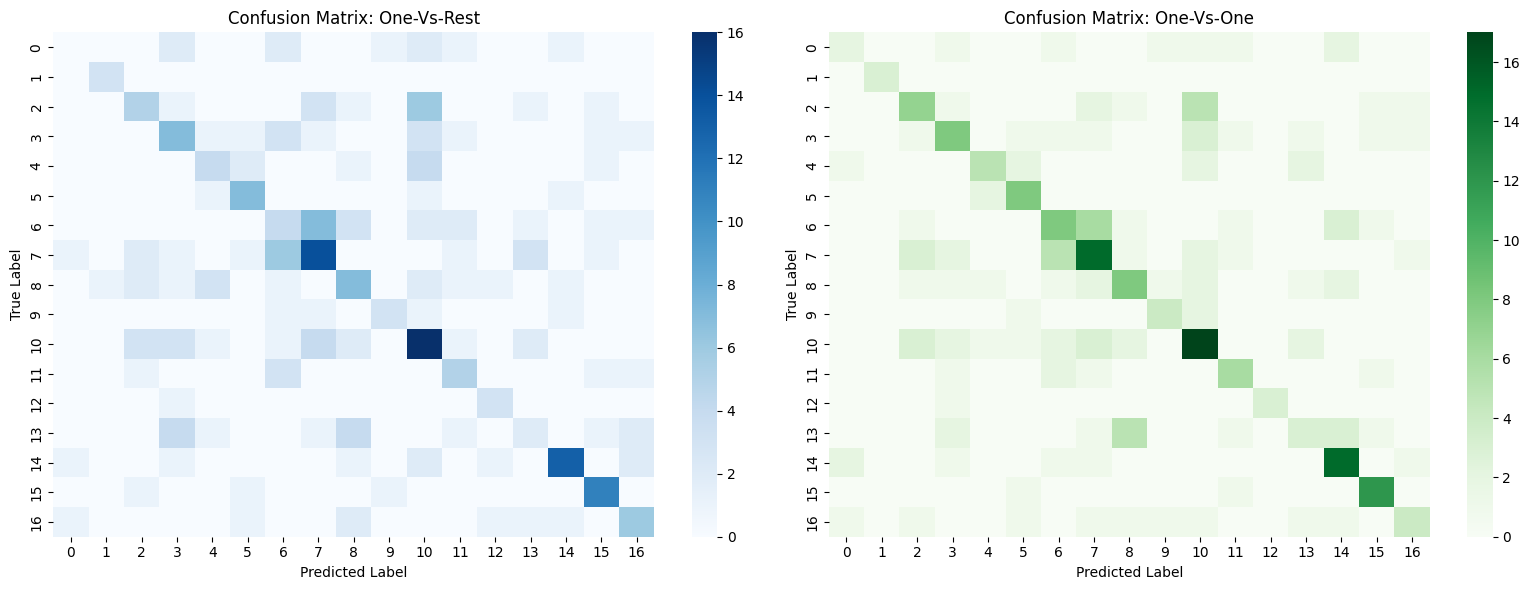

In [4]:
# Present the results of both models using classification reports and confusion matrices.
y_pred_ovr = pipeline_ovr.predict(X_test)
y_pred_ovo = pipeline_ovo.predict(X_test)

print("==================== OneVsRestClassifier ====================")
print(classification_report(y_test, y_pred_ovr, zero_division=0))

print("\n==================== OneVsOneClassifier =====================")
print(classification_report(y_test, y_pred_ovo, zero_division=0))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_ovr), annot=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: One-Vs-Rest')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_ovo), annot=False, cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: One-Vs-One')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


Answer the following questions:

**1. Which multiclass SVM implementation (OneVsRestClassifier or OneVsOneClassifier) performed better on the test set? Why do you think that is the case?**

OneVsOneClassifier distinctly outperformed the OneVsRestClassifier for me. Looking at my results, OVO got an accuracy of about 49% with an F1 of 0.53, while OVR was stuck down at 42% accuracy and an F1 of 0.44. I think the biggest reason for this is how OVR handles class imbalance. In OVR, the model has to compare one single committee against every other committee combined. Because our data covers 17 different classes, that means the model is constantly looking at massively skewed datasets during training, which makes it really hard to draw a clean boundary. OVO avoids this by only comparing two specific committees at a time, making the sub-tasks much more balanced and focused.

**2. How does the choice of kernel affect the performance of the SVM model? What other kernels might be worth trying for this dataset?**

The kernel shows the actual geometric shape of the decision boundary that the SVM draws. In this notebook we used a linear kernel, which assumes that we can easily slice the committees apart with flat hyperplanes. But thinking back to the EDA notebook where the PCA looked like a massive blob, we know these text embeddings are highly complex and overlapping. The linear kernel is just too rigid for that. 
If I were tuning this further, I would definitely want to try an RBF (Radial Basis Function) or Polynomial kernel. Those are much better at capturing intricate, non-linear lexical relationships by calculating similarities in a higher-dimensional space.

**3. Do you think SVM is a good model for this dataset? Why or why not? What other models might be worth trying?**

Honestly, I don't think standard SVMs are the best approach for this specific dataset. Multiclass SVMs generally struggle when we have large, highly intersecting clusters, because defining clear margin boundaries becomes almost impossible without severely overfitting. Also, tuning 17-class OVO on 384 dimensions was really computationally slow. If I were building this from scratch, I'd lean toward tree ensembles like a RandomForestClassifier or XGBoost, since they naturally handle non-linear interactions and give great feature importance. 